I. Обработка пропущенных значений.

In [16]:
import pandas as pd
import numpy as np
mtcars = pd.read_csv('./mtcars.csv')
print(mtcars.isna().sum().sum()) 

0


In [17]:
dat = mtcars.copy()
dat.loc[[1, 3, 9], 'mpg'] = np.nan
print(dat.isna().sum().sum())
print(np.where(dat.isna()))
print(dat['mpg'].iloc[[1, 3, 9]])

3
(array([1, 3, 9]), array([1, 1, 1]))
1   NaN
3   NaN
9   NaN
Name: mpg, dtype: float64


In [18]:
dat1 = dat.dropna()
dat2 = dat.drop(columns=[dat.columns[0]])

Закоментил теста инпутера ради

In [19]:
mean_val = dat['mpg'].mean()
#dat.loc[1, 'mpg'] = mean_val
median_val = dat['mpg'].median()
#dat.loc[3, 'mpg'] = median_val
#dat.loc[9, 'mpg'] = 13

In [20]:
from sklearn.impute import SimpleImputer

In [21]:
imputer_mean = SimpleImputer(strategy='mean')
G1 = imputer_mean.fit_transform(dat[['mpg']]).flatten()
imputer_median = SimpleImputer(strategy='median')
G2 = imputer_median.fit_transform(dat[['mpg']]).flatten()
imputer_constant = SimpleImputer(strategy='constant', fill_value=13)
G3 = imputer_constant.fit_transform(dat[['mpg']]).flatten()

In [22]:
print(pd.Series(dat['mpg']).describe())
print(pd.Series(G1).describe())
print(pd.Series(G2).describe())
print(pd.Series(G3).describe())

count    29.000000
mean     20.044828
std       6.332038
min      10.400000
25%      15.200000
50%      18.700000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64
count    32.000000
mean     20.044828
std       6.017854
min      10.400000
25%      15.425000
50%      19.450000
75%      22.800000
max      33.900000
dtype: float64
count    32.000000
mean     19.918750
std       6.031019
min      10.400000
25%      15.425000
50%      18.700000
75%      22.800000
max      33.900000
dtype: float64
count    32.000000
mean     19.384375
std       6.369236
min      10.400000
25%      14.925000
50%      17.950000
75%      22.800000
max      33.900000
dtype: float64


Тут в методичке что-то в dat есть стр столбец с моделью авто. Я колонку дропнул, иначе не пропускает.

In [26]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer()
numeric_dat = dat.drop(columns=['model'])
dat_imputed = imputer.fit_transform(numeric_dat)
dat_imputed = pd.DataFrame(dat_imputed, columns=numeric_dat.columns)

In [30]:
print(dat_imputed.isna().sum())

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64


II. Выбросы

In [32]:
x = [
    4.27296076175273, 4.3253044335640, 4.55202839528403,
    4.33285651824668, 4.0128340310945, 4.07155452370293,
    4.04113475664987, 2.7753693269563, 2.49186430883914,
    2.39823431758359, 2.3789955162936, 2.14825292752989,
    2.19583315284264, 2.1947104626036, 2.14216783486566,
    2.28399128121205, 2.3048696257819, 2.23703873535593,
    2.28669486582313, 2.4163169738317, 2.03782758779637,
    2.61237703056071, 3.47620332697605
]

y = [
    9.097731, 9.512591, 9.740439, 9.910364, 9.865059, 9.935519,
    9.972640, 9.920197, 10.367693, 10.680861, 10.999012, 11.246248,
    10.532816, 11.144033, 11.261961, 11.400160, 11.080695, 11.173922,
    11.506877, 11.105483, 10.807685, 6.489205, 4.882802
] 

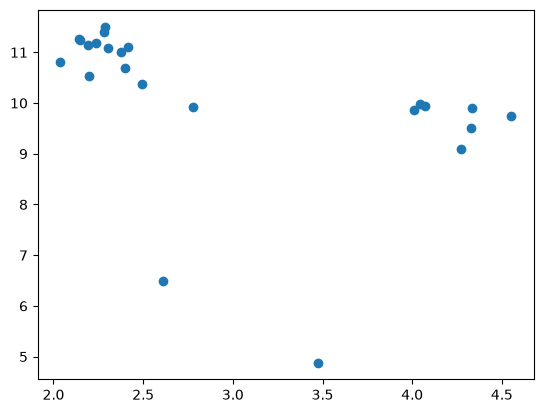

In [33]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

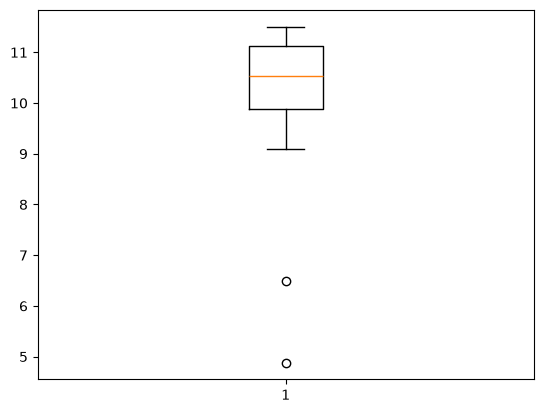

In [34]:
plt.boxplot(y)
plt.show()

In [35]:
q1 = np.quantile(y, 0.25)
q3 = np.quantile(y, 0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = [val for val in y if val < lower_bound or val > upper_bound]
ind = [i for i, val in enumerate(y) if val in outliers]

In [36]:
outlier_df = pd.DataFrame({'x': [x[i] for i in ind], 'y': [y[i] for i in ind]})

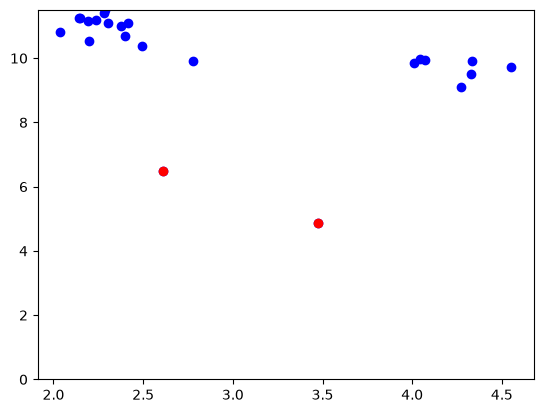

In [37]:
plt.scatter(x, y, color='blue', marker='o')
plt.scatter(outlier_df['x'], outlier_df['y'], color='red', marker='o')
plt.ylim(0, max(y))
plt.show()

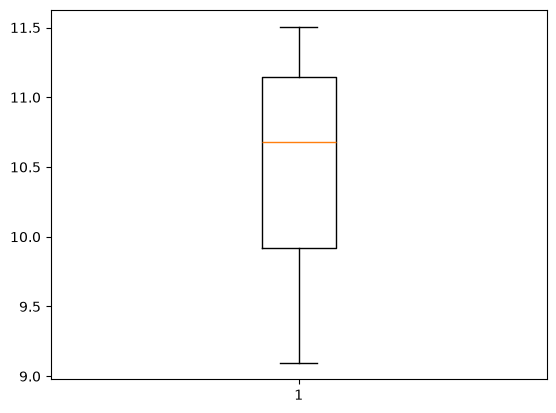

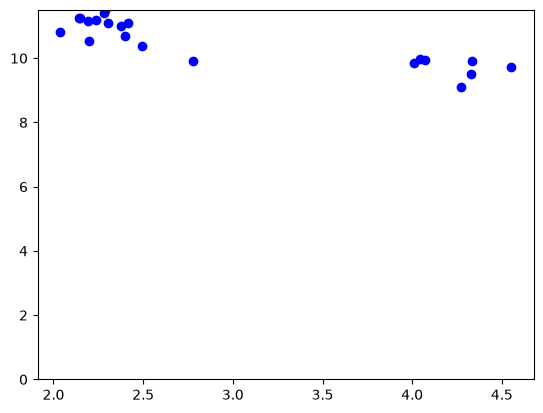

In [38]:
x_clean = [x[i] for i in range(len(x)) if i not in ind]
y_clean = [y[i] for i in range(len(y)) if i not in ind]
plt.boxplot(y_clean)
plt.show()
plt.scatter(x_clean, y_clean, color='blue', marker='o')
plt.ylim(0, max(y_clean))
plt.show()

In [42]:
from outliers import smirnov_grubbs as grubbs
data = [5, 14, 15, 15, 14, 13, 19, 17, 16, 20, 22, 8, 21, 28, 11, 9, 29, 40]

In [43]:
# Проверка максимального значения
result = grubbs.test(data, alpha=0.05)
print(f"Выбросы: { set(data)-set(result) }")

Выбросы: {40}


In [44]:
# Проверка минимального значения
result_opposite = grubbs.min_test(data, alpha=0.05)
print(f"Минимальный выброс: { set(data)-set(result_opposite) }")

Минимальный выброс: set()


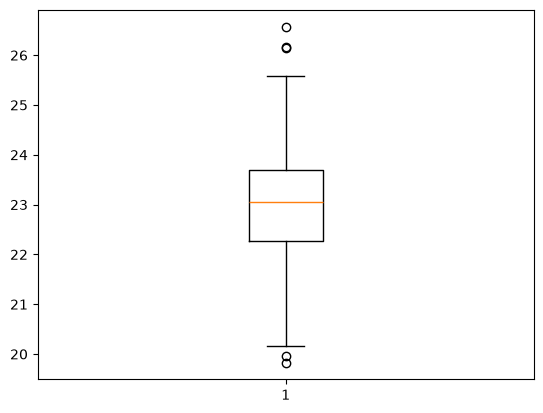

count    500.000000
mean      22.994335
std        1.039181
min       19.828594
25%       22.278574
50%       23.046769
75%       23.685284
max       26.574295
dtype: float64
Нижняя граница: 20.939875613536632
Верхняя граница: 25.15366188689727


In [46]:
from scipy.stats import median_abs_deviation

x = np.random.normal(23, 1, 500)

plt.boxplot(x)
plt.show()

print(pd.Series(x).describe())

mad = median_abs_deviation(x)
median_val = np.median(x)

lower_bound = median_val - 3 * mad
upper_bound = median_val + 3 * mad

print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")

In [47]:
outlier_ind = np.where((x < lower_bound) | (x > upper_bound))[0]
print(f"Индексы выбросов: {outlier_ind}")

print(f"Значение выброса с индексом {outlier_ind[0]}: {x[outlier_ind[0]]}")
print(f"Значение выброса с индексом {outlier_ind[-1]}: {x[outlier_ind[-1]]}")

Индексы выбросов: [ 22  78  87  96 162 165 182 243 270 274 339 368 371 385 437 448 453 473]
Значение выброса с индексом 22: 20.36549547850806
Значение выброса с индексом 473: 19.828594461330113


**Самостоятельное задание**

In [50]:
df = pd.read_csv('./InsectSprays.csv')

In [55]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  72 non-null     int64
 1   count       72 non-null     int64
 2   spray       72 non-null     str  
dtypes: int64(2), str(1)
memory usage: 1.8 KB
None


In [51]:
print(df.isna().sum())

Unnamed: 0    0
count         0
spray         0
dtype: int64


1 Постройте диаграмму размаха показателя InsectSprays[count], а также диаграмму размаха показателя InsectSprays[count] по видам инсектицидных средств.

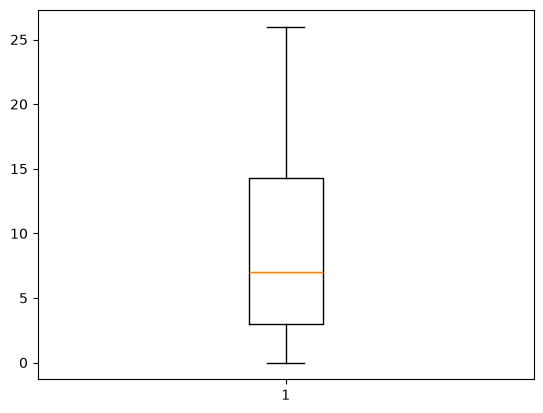

In [56]:
plt.boxplot(df['count'])
plt.show()

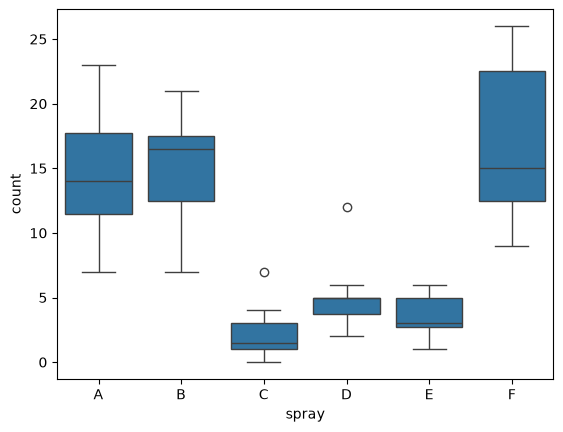

In [61]:
import seaborn as sns
sns.boxplot(y=df['count'], x=df['spray'])
plt.show()

2 Определите выбросы в данных по видам инсектицидных средств, используя разные методы.


In [85]:
A = df[df['spray'] == 'A']['count']
B = df[df['spray'] == 'B']['count']
C = df[df['spray'] == 'C']['count']
D = df[df['spray'] == 'D']['count']
E = df[df['spray'] == 'E']['count']
F = df[df['spray'] == 'F']['count']


Тест Граббса

In [87]:
result_A = grubbs.test(A.tolist(), alpha=0.05)

print("Выбросы A:", set(A) - set(result_A))
result_B = grubbs.test(B.tolist(), alpha=0.05)

print("Выбросы B:", set(B) - set(result_B))

Выбросы A: set()
Выбросы B: set()


Квантили

In [88]:
C = df[df['spray'] == 'C']['count']

Q1 = C.quantile(0.25)
Q3 = C.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = C[(C < lower_bound) | (C > upper_bound    )]

print("Выбросы C:")
print(outliers)

Выбросы C:
26    7
Name: count, dtype: int64


In [84]:
D = df[df['spray'] == 'D']['count']

Q1 = D.quantile(0.25)
Q3 = D.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = D[(D < lower_bound) | (D > upper_bound    )]

print("Выбросы D:")
print(outliers)

Выбросы D:
38    12
Name: count, dtype: int64


Фильтр Хэмпеля

In [90]:
E = df[df['spray'] == 'E']['count']

mediana = E.median()
MAD = (E - mediana).abs().median()

k = 3

lower = mediana - k * MAD
upper = mediana + k * MAD

outliers = E[(E < lower) | (E > upper)]

print(outliers)

Series([], Name: count, dtype: int64)


In [91]:
F = df[df['spray'] == 'F']['count']

mediana = F.median()
MAD = (F - mediana).abs().median()

k = 3

lower = mediana - k * MAD
upper = mediana + k * MAD

outliers = F[(F < lower) | (F > upper)]

print(outliers)

Series([], Name: count, dtype: int64)
